# Árvore de decisão do zero

**Tema:** Aprendizado Supervisionado › Árvores de Decisão

Este notebook implementa uma árvore de classificação do zero — Gini,
ganho de informação, particionamento recursivo guloso — e confirma contra
`sklearn.DecisionTreeClassifier`. Depois mede diretamente a instabilidade:
pequenas mudanças no treino produzindo árvores estruturalmente diferentes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification

rng = np.random.default_rng(31)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Gini e ganho de informação, na mão

In [2]:
def gini(y):
    if len(y) == 0:
        return 0.0
    proporcoes = np.bincount(y) / len(y)
    return 1 - np.sum(proporcoes ** 2)


def ganho_de_informacao(y_pai, y_esquerda, y_direita):
    n = len(y_pai)
    impureza_pai = gini(y_pai)
    impureza_filhos = (len(y_esquerda) / n) * gini(y_esquerda) + \
        (len(y_direita) / n) * gini(y_direita)
    return impureza_pai - impureza_filhos


y_exemplo = np.array([0, 0, 0, 1, 1, 1, 1, 1])
print(f"Gini de um nó puro (só classe 0): {gini(np.array([0,0,0,0])):.4f}")
print(f"Gini de um nó 50/50            : {gini(np.array([0,0,1,1])):.4f}")
print(f"Gini do exemplo (3 vs 5)        : {gini(y_exemplo):.4f}")

Gini de um nó puro (só classe 0): 0.0000
Gini de um nó 50/50            : 0.5000
Gini do exemplo (3 vs 5)        : 0.4688


## 2. O algoritmo completo: melhor corte, recursão, parada

In [3]:
class NoDaArvore:
    def __init__(self, profundidade=0):
        self.profundidade = profundidade
        self.feature, self.limiar = None, None
        self.esquerda, self.direita = None, None
        self.previsao = None  # só preenchido em folhas


def melhor_corte(X, y):
    melhor_ganho, melhor_feature, melhor_limiar = -1, None, None
    for feature in range(X.shape[1]):
        valores_unicos = np.unique(X[:, feature])
        limiares_candidatos = (valores_unicos[:-1] + valores_unicos[1:]) / 2
        for limiar in limiares_candidatos:
            mascara_esquerda = X[:, feature] <= limiar
            if mascara_esquerda.sum() == 0 or (~mascara_esquerda).sum() == 0:
                continue
            ganho = ganho_de_informacao(y, y[mascara_esquerda], y[~mascara_esquerda])
            if ganho > melhor_ganho:
                melhor_ganho, melhor_feature, melhor_limiar = ganho, feature, limiar
    return melhor_feature, melhor_limiar, melhor_ganho


def constroi_arvore(X, y, profundidade=0, max_profundidade=4, min_amostras_folha=5):
    no = NoDaArvore(profundidade)
    if (profundidade >= max_profundidade or len(y) < 2 * min_amostras_folha
            or gini(y) == 0):
        no.previsao = np.bincount(y).argmax()
        return no

    feature, limiar, ganho = melhor_corte(X, y)
    if feature is None or ganho <= 1e-12:
        no.previsao = np.bincount(y).argmax()
        return no

    no.feature, no.limiar = feature, limiar
    mascara = X[:, feature] <= limiar
    no.esquerda = constroi_arvore(X[mascara], y[mascara], profundidade + 1,
                                  max_profundidade, min_amostras_folha)
    no.direita = constroi_arvore(X[~mascara], y[~mascara], profundidade + 1,
                                 max_profundidade, min_amostras_folha)
    return no


def prediz_um(no, x):
    if no.previsao is not None:
        return no.previsao
    if x[no.feature] <= no.limiar:
        return prediz_um(no.esquerda, x)
    return prediz_um(no.direita, x)


def prediz(no, X):
    return np.array([prediz_um(no, x) for x in X])

## 3. Confirmando contra sklearn

In [4]:
X, y = make_classification(n_samples=400, n_features=4, n_informative=3,
                           n_redundant=0, random_state=0)

arvore_manual = constroi_arvore(X, y, max_profundidade=4, min_amostras_folha=5)
pred_manual = prediz(arvore_manual, X)

arvore_sklearn = DecisionTreeClassifier(
    criterion="gini", max_depth=4, min_samples_leaf=5, random_state=0).fit(X, y)
pred_sklearn = arvore_sklearn.predict(X)

print(f"acurácia de treino (manual) : {(pred_manual == y).mean():.4f}")
print(f"acurácia de treino (sklearn): {(pred_sklearn == y).mean():.4f}")
print(f"concordância entre as duas implementações: {(pred_manual == pred_sklearn).mean():.1%}")

acurácia de treino (manual) : 0.9225
acurácia de treino (sklearn): 0.9150
concordância entre as duas implementações: 98.8%


## 4. Overfitting sem limite de profundidade

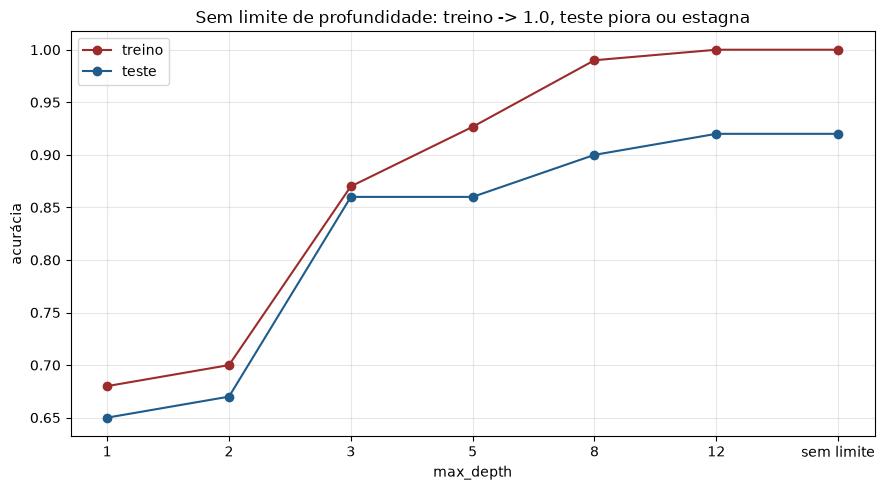

max_depth      acc treino    acc teste
--------------------------------------
1                  0.6800       0.6500
2                  0.7000       0.6700
3                  0.8700       0.8600
5                  0.9267       0.8600
8                  0.9900       0.9000
12                 1.0000       0.9200
sem limite         1.0000       0.9200


In [5]:
X_treino, X_teste = X[:300], X[300:]
y_treino, y_teste = y[:300], y[300:]

profundidades = [1, 2, 3, 5, 8, 12, None]
acc_treino, acc_teste = [], []
for prof in profundidades:
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=0).fit(X_treino, y_treino)
    acc_treino.append(modelo.score(X_treino, y_treino))
    acc_teste.append(modelo.score(X_teste, y_teste))

rotulos_x = [str(p) if p else "sem limite" for p in profundidades]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rotulos_x, acc_treino, "o-", color=VERMELHO, label="treino")
ax.plot(rotulos_x, acc_teste, "o-", color=AZUL, label="teste")
ax.set_xlabel("max_depth"); ax.set_ylabel("acurácia")
ax.set_title("Sem limite de profundidade: treino -> 1.0, teste piora ou estagna")
ax.legend(); plt.tight_layout(); plt.show()

print(f"{'max_depth':<12s} {'acc treino':>12s} {'acc teste':>12s}")
print("-" * 38)
for prof, at, ate in zip(rotulos_x, acc_treino, acc_teste):
    print(f"{prof:<12s} {at:>12.4f} {ate:>12.4f}")

## 5. Instabilidade: a mesma pergunta, respostas estruturalmente diferentes

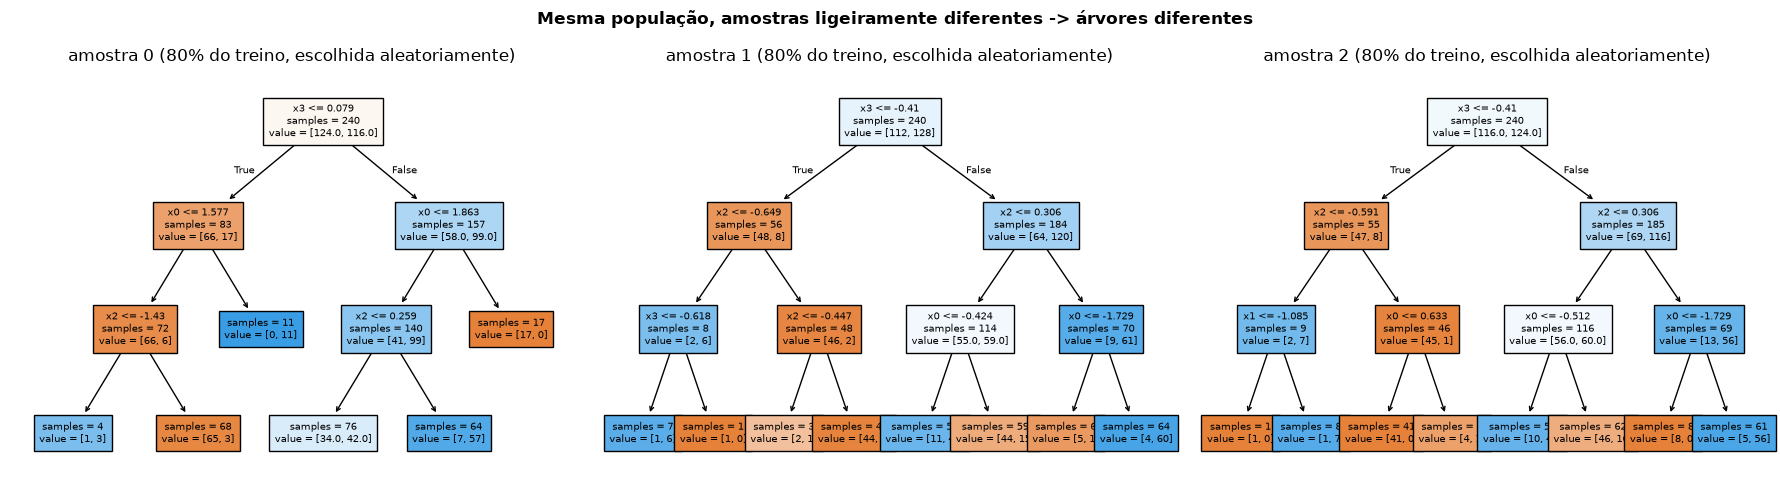

Repare: o PRIMEIRO corte (a raiz) já pode usar features diferentes
dependendo de qual 80% do treino foi sorteado — a assinatura da alta
variância que o módulo 7 (Random Forest) vai explorar a favor do modelo.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, seed in zip(axes, [0, 1, 2]):
    rng_local = np.random.default_rng(seed)
    indices_amostra = rng_local.choice(len(X_treino), size=int(0.8 * len(X_treino)),
                                       replace=False)
    modelo = DecisionTreeClassifier(max_depth=3, random_state=0).fit(
        X_treino[indices_amostra], y_treino[indices_amostra])
    plot_tree(modelo, ax=ax, feature_names=[f"x{i}" for i in range(4)],
             filled=True, fontsize=7, impurity=False)
    ax.set_title(f"amostra {seed} (80% do treino, escolhida aleatoriamente)")
plt.suptitle("Mesma população, amostras ligeiramente diferentes -> árvores diferentes",
             fontweight="bold")
plt.tight_layout(); plt.show()

print("Repare: o PRIMEIRO corte (a raiz) já pode usar features diferentes")
print("dependendo de qual 80% do treino foi sorteado — a assinatura da alta")
print("variância que o módulo 7 (Random Forest) vai explorar a favor do modelo.")

## O que levar deste notebook

- O algoritmo de árvore é, literalmente, testar todo corte possível e
  escolher o que mais reduz o Gini — a implementação do zero confirma isso
  linha por linha contra `sklearn`.
- Sem limite de profundidade, a árvore memoriza o treino (acurácia de
  treino tende a 1.0) e a generalização sofre — o retrato mais claro de
  overfitting do curso até aqui.
- Pequenas mudanças na amostra de treino podem mudar a estrutura inteira
  da árvore, começando pela própria raiz — instabilidade mensurável, não
  só uma afirmação teórica.

→ Próximo: **Poda e hiperparâmetros**, as ferramentas para controlar esse
comportamento.